# Regional subplate thickness demo (left hemisphere)

Maps **per-vertex subplate thickness** onto the **fetal21 regional atlas**
(template-29 space) for a single example subject/split.

- **Thickness** (`lh.innersp.native.thk`) — per-vertex subplate thickness, i.e.
  the native-space distance between the inner-subplate surface (`innersp`) and the
  outer boundary (`wm`), generated by `src/processing/generate_native_surfaces.py`.
  **This is *not* the CIVET `*.smoothwm.native_81920.thk`, which is cortical-plate
  thickness** — plotting that here is what made the earlier numbers look wrong.
- **Regional atlas** (`lh.fetal21.1D.dset`) — one region label per vertex, same
  40,962-vertex template mesh. The subplate surfaces are deformed from the CIVET
  WM mesh (verified: `wm..native` vs `smoothwm.native` agree to ~1.3 mm, i.e. same
  vertex ordering), so the atlas label vector applies to them by index.
- **Label names** (`21_annotation.csv`) — maps label id → ROI name + lobe.

LH only — the atlas provided is left-hemisphere. Example subject must have a
successful subplate extraction (FCB187 did not — it has no `default_surfaces`).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # noqa: F401 (registers 3d)

# --- paths (single example subject/split with a successful subplate extraction) ---
SUBJ  = ("/neuro/labs/grantlab/research/MRI_processing/seungyoon.jeong/2025/"
         "Reliability/TEST/FCB155/2019.06.25-032Y-MR_EI_Fetal_Neuro-29190/S1")
ATLAS = "/neuro/users/mri.team/fetal_mri/Surface_template/template-29/old/lh.fetal21.1D.dset"
ANNOT = "/neuro/labs/grantlab/research/andrea.gondova/21_annotation.csv"

# SUBPLATE thickness (|innersp - wm| in native mm), one value per vertex.
# NOT the CIVET cortical-plate .thk in surfaces/.
THK   = f"{SUBJ}/default_surfaces/lh.innersp.native.thk"
# Render the map on the native inner-subplate surface.
# (swap to lh.wm..native.obj to render on the outer boundary instead.)
OBJ   = f"{SUBJ}/default_surfaces/lh.innersp.native.obj"


In [3]:
def read_mni_obj(path):
    """Parse a BIC/MNI `.obj` surface: returns (vertices[N,3], faces[M,3])."""
    with open(path) as f:
        t = f.read().split()
    assert t[0] == "P", "not a polygon .obj"
    n = int(t[6]); i = 7
    verts = np.array(t[i:i + 3 * n], dtype=float).reshape(n, 3); i += 3 * n
    i += 3 * n                       # skip per-vertex normals
    n_items = int(t[i]); i += 1
    colflag = int(t[i]); i += 1      # colour info block
    i += 4 if colflag == 0 else (4 * n_items if colflag == 1 else 4 * n)
    end = np.array(t[i:i + n_items], dtype=int); i += n_items
    conn = np.array(t[i:i + end[-1]], dtype=int)
    return verts, conn.reshape(n_items, 3)


labels = np.loadtxt(ATLAS).astype(int)      # (40962,) region id per vertex
thk    = np.loadtxt(THK)                     # (40962,) subplate thickness (mm) per vertex
verts, faces = read_mni_obj(OBJ)             # geometry for rendering
annot  = pd.read_csv(ANNOT)

assert labels.shape == thk.shape == (verts.shape[0],), "vertex count mismatch!"
print(f"{len(thk):,} vertices | {faces.shape[0]:,} triangles | "
      f"{annot['label_21'].nunique()} atlas regions")
print(f"subplate thickness (mm): mean {thk.mean():.2f}  "
      f"median {np.median(thk):.2f}  range {thk.min():.2f}-{thk.max():.2f}")


40,962 vertices | 81,920 triangles | 22 atlas regions
subplate thickness (mm): mean 2.10  median 2.07  range 0.03-4.40


In [4]:
lut = dict(zip(annot["label_21"], annot["ROI_21"]))
df = pd.DataFrame({"label": labels, "thickness": thk})
df["region"] = df["label"].map(lut)

# Subplate thickness is a positive per-vertex distance; keep vertices with a
# named atlas region (drops any unlabelled vertices).
valid = df[(df["thickness"] > 0) & df["region"].notna()]
region_summary = (valid.groupby(["label", "region"])["thickness"]
                  .agg(mean="mean", std="std", n="count")
                  .reset_index()
                  .sort_values("mean", ascending=False))
region_summary.round(3)


,label,region,mean,std,n
20,20,supramarginal gyrus,3.557,0.655,1359
19,19,superior temporal gyrus,3.150,0.516,1946
21,21,postcentral gyrus,3.035,0.544,1968
6,6,inferior parietal cortex,2.759,0.531,1824
14,14,middle temporal gyrus,2.669,0.283,1422
17,17,inferior frontal gyrus,2.643,0.596,1356
4,4,precentral gyrus,2.500,0.637,2277
15,15,paracentral lobule,2.427,0.357,706
9,9,precuneus cortex,2.341,0.509,1770
18,18,superior parietal cortex,2.316,0.268,1838


### Per-region mean subplate thickness

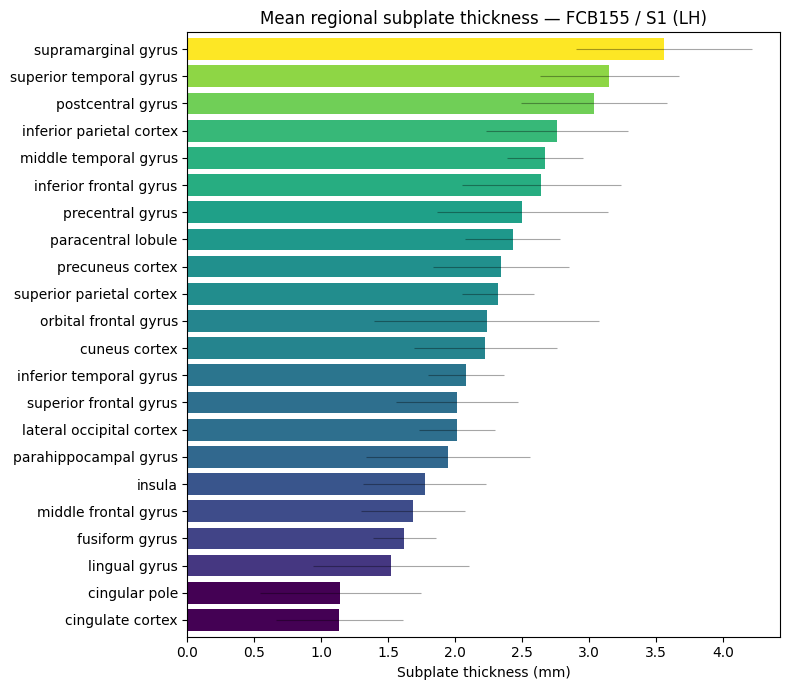

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
rs = region_summary.sort_values("mean")
ax.barh(rs["region"], rs["mean"], xerr=rs["std"],
        color=plt.cm.viridis((rs["mean"] - rs["mean"].min()) /
                             (rs["mean"].max() - rs["mean"].min())),
        error_kw=dict(alpha=0.35, lw=0.8))
ax.set_xlabel("Subplate thickness (mm)")
ax.set_title("Mean regional subplate thickness — FCB155 / S1 (LH)")
ax.margins(y=0.01)
plt.tight_layout()
plt.show()


### Subplate thickness mapped onto the subplate surface

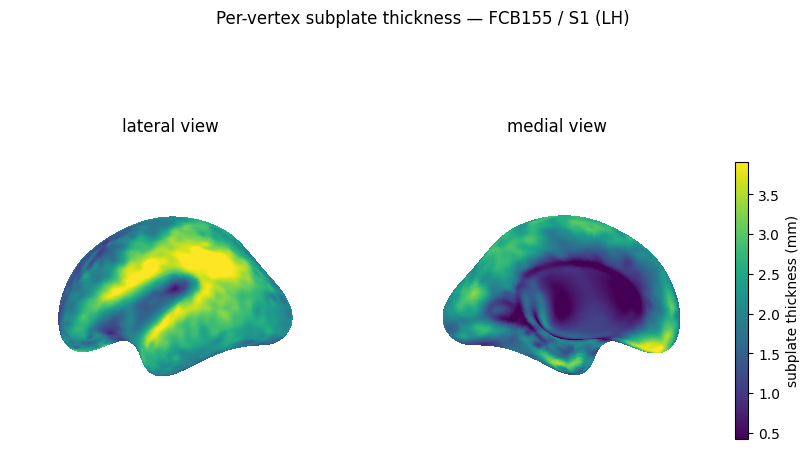

In [8]:
def plot_surface(scalar, title, cmap="viridis", clip=(2, 98)):
    """Render the LH surface, colouring each triangle by mean vertex scalar."""
    face_vals = scalar[faces].mean(axis=1)
    vmin, vmax = np.percentile(scalar[scalar > 0], clip)
    fig = plt.figure(figsize=(11, 6))
    for k, (elev, azim, lab) in enumerate([(0, 180, "lateral"),
                                           (0, 0, "medial")]):
        ax = fig.add_subplot(1, 2, k + 1, projection="3d")
        tri = ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2],
                              triangles=faces, cmap=cmap,
                              vmin=vmin, vmax=vmax, linewidth=0,
                              antialiased=False, shade=False)
        tri.set_array(face_vals)
        ax.view_init(elev=elev, azim=azim)
        ax.set_axis_off()
        ax.set_title(f"{lab} view")
        ax.set_box_aspect(np.ptp(verts, axis=0))
    fig.suptitle(title, y=0.98)
    cb = fig.colorbar(tri, ax=fig.axes, shrink=0.6, pad=0.02)
    cb.set_label("subplate thickness (mm)")
    plt.show()


plot_surface(thk, "Per-vertex subplate thickness — FCB155 / S1 (LH)")


Same surface, but each vertex painted with its **region's mean subplate thickness** — shows the atlas parcellation driving the regional summary above.

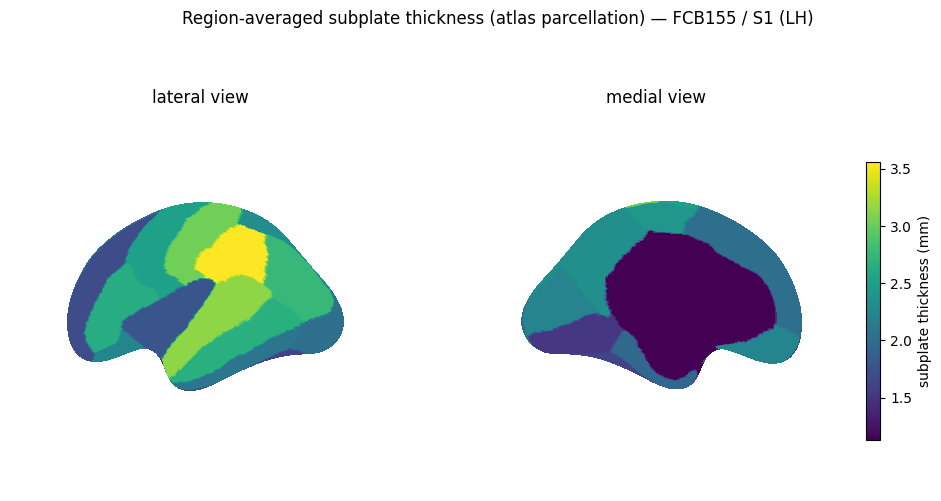

In [6]:
region_mean_lut = region_summary.set_index("label")["mean"].to_dict()
vertex_region_mean = np.array([region_mean_lut.get(l, 0.0) for l in labels])
plot_surface(vertex_region_mean,
             "Region-averaged subplate thickness (atlas parcellation) — FCB155 / S1 (LH)")
